# FNCE 449 Day 4 Assignment: A Machine Learning Trading Algo

### Data preparation tasks (15p)

1. (**Data prep**) Load *iShares TSX 60* (XIU.TO) order book data from `https://github.com/mariuszoican/mgt443/blob/main/Data/XIU_TAQ.csv?raw=true`.   
The file contains 378,376 quote updates for XIU.TO from March 11, 2020.

2. (**Data prep**) Convert the `Date-Time` column into native `pandas` dates, and add the GMT Offset to obtain local Toronto time.  
*Hint*: to add the `GMT Offset` you may apply the inline function `lambda x: dt.timedelta(hours=x)` to the appropriate column.

3. (**Data prep**) Select only quote updates between 9:30 AM and 3:30 PM (to avoid overnight and opening/closing auction effects).

4. (**Resample**) Resample the data such that you only retain the last observation for each second.   
Forward-fill any missing observations (i.e., with no updates in that second).  
*Hint*: you may use `.resample('1S').last()`.

### Variable building (20p)

5. (**Midpoint**) Compute the midpoint for each row as 

$$\text{Midpoint}=\frac{\text{Bid Price}+\text{Ask Price}}{2}.$$  

6. (**Tick change**) Generate a dummy `Tick` that takes the value:
      1. 1 if the next-second midpoint is higher than the current midpoint;
      2. 0 if the next-second midpoint is lower or equal to the current midpoint;
   
7. (**Depth**) Compute the market depth for each row as

$$\text{Depth}=\text{Ask size}+\text{Bid size}.$$

8. (**Order imbalance**) Compute the order imbalance for each row as 

$$\text{Order Imbalance}=\frac{\text{Ask size}-\text{Bid size}}{\text{Depth}}.$$

9. (**Bid ask spread**) Compute the quoted bid-ask spread as:

$$\text{Bid-ask spread}=\frac{\text{Ask price}-\text{Bid price}}{\text{Midpoint}}.$$

10. (**First differences**) Generate columns for the change in depth and order imbalance from the previous second to the current one.

11. (**Rolling mean**) Generate two columns for the rolling mean of depth and order imbalance, using a rolling window of 10 rows. You can use the `Series.rolling` method.   
Further, generate two dummies taking value 1 if the current depth/**absolute** order imbalance is above their rolling mean, and zero else.

### Logistic regression prediction (40p)

10. Split the data into equally-sized `train` and `test` samples.
11. Use a logistic regression to predict future midpoint movements using:

    1. Market depth and its first difference;
    2. Order imbalance and its first difference;
    3. Bid-ask spread;
    4. Whether the depth is above rolling mean or not;
    5. Whether the absolute order imbalance is above rolling mean or not.
    
    In estimating the logistic regression, use `solver='lbfgs'` rather than `solver='newton-cg'` (better convergence).  
    You will not be able to estimate the logistic regression with `NaN` values, so you need to delete them. 
    
12. Plot the ROC curve and assess the predictive power of your model.

### Testing the algorithm (25p)

Set a threshold probability $q$ (e.g., the median predicted probability of an uptick) such that you always buy when the predicted probability is larger than $q$, and sell in the next second. That way, you don't accumulate a position.

1. What is your profit if you buy and sell always at the prevailing mid-point?
2. What is your profit if you buy at the ask price and sell at the bid price?
3. How many trades are profitable in either case?

Reflect on the importance of transaction costs and the difference between predictive power and strategy implementation.

---

# Solution

Structure follows the assignment: **data prep** (Q1-4) &rarr; **variable building** (Q5-11) &rarr; **logistic regression** (Q10-12) &rarr; **strategy backtest** (Q1-3 + reflection).

In [1]:
# Setup
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, roc_auc_score, accuracy_score,
                             classification_report)

plt.style.use("seaborn-v0_8-whitegrid")
print("Imports ready.")

Imports ready.


## Data preparation (Q1-4)

In [2]:
# Q1: Load the XIU.TO order book (quote) data
url = "https://github.com/mariuszoican/mgt443/blob/main/Data/XIU_TAQ.csv?raw=true"
taq = pd.read_csv(url)
taq = taq.drop(columns=["Unnamed: 0"])

print(f"Loaded {len(taq):,} quote updates")
taq.head()

Loaded 378,376 quote updates


,#RIC,Date-Time,GMT Offset,Bid Price,Bid Size,Ask Price,Ask Size
0,XIU.TO,2020-03-11T08:14:07.064395479Z,-4,22.31,10.0,22.51,1.0
1,XIU.TO,2020-03-11T11:00:33.865394114Z,-4,22.51,1.0,22.51,1.0
2,XIU.TO,2020-03-11T11:00:34.281579614Z,-4,22.60,21.0,22.60,28.0
3,XIU.TO,2020-03-11T11:00:38.441554897Z,-4,22.60,24.0,22.60,28.0
4,XIU.TO,2020-03-11T11:00:45.582002088Z,-4,22.60,28.0,22.60,28.0


In [3]:
# Q2: Parse Date-Time (UTC) and add the GMT Offset to get local Toronto time
taq["Date-Time"] = pd.to_datetime(taq["Date-Time"], format="ISO8601", utc=True)
taq["Date-Time"] = taq["Date-Time"] + taq["GMT Offset"].apply(lambda x: dt.timedelta(hours=x))

# drop the tz label: the stamps are now Toronto wall-clock time
taq["Date-Time"] = taq["Date-Time"].dt.tz_localize(None)

print(f"GMT offset(s) in file : {taq['GMT Offset'].unique()}")
print(f"First quote (Toronto) : {taq['Date-Time'].min()}")
print(f"Last quote  (Toronto) : {taq['Date-Time'].max()}")
taq.head()

GMT offset(s) in file : [-4]
First quote (Toronto) : 2020-03-11 04:14:07.064395479
Last quote  (Toronto) : 2020-03-11 16:42:24.483427363


,#RIC,Date-Time,GMT Offset,Bid Price,Bid Size,Ask Price,Ask Size
0,XIU.TO,2020-03-11 04:14:07.064395479,-4,22.31,10.0,22.51,1.0
1,XIU.TO,2020-03-11 07:00:33.865394114,-4,22.51,1.0,22.51,1.0
2,XIU.TO,2020-03-11 07:00:34.281579614,-4,22.60,21.0,22.60,28.0
3,XIU.TO,2020-03-11 07:00:38.441554897,-4,22.60,24.0,22.60,28.0
4,XIU.TO,2020-03-11 07:00:45.582002088,-4,22.60,28.0,22.60,28.0


In [4]:
# Q3: Keep only continuous-trading quotes, 9:30 AM - 3:30 PM local
quotes = taq.set_index("Date-Time").sort_index()
quotes = quotes[["Bid Price", "Bid Size", "Ask Price", "Ask Size"]].between_time("09:30", "15:30")

print(f"Quote updates inside 09:30-15:30 : {len(quotes):,}  ({len(quotes)/len(taq):.1%} of the raw file)")
quotes.head()

Quote updates inside 09:30-15:30 : 340,141  (89.9% of the raw file)


,Bid Price,Bid Size,Ask Price,Ask Size
Date-Time,,,,
2020-03-11 09:30:00.130026193,22.00,52.0,22.03,97.0
2020-03-11 09:30:00.281588277,22.00,52.0,22.01,820.0
2020-03-11 09:30:00.287082134,21.93,360.0,21.95,170.0
2020-03-11 09:30:00.287155815,21.93,32.0,21.95,170.0
2020-03-11 09:30:00.287155815,21.90,209.0,21.95,170.0


In [5]:
# Q4: Resample to one observation per second (last quote in the second), forward-fill empty seconds
book = quotes.resample("1s").last().ffill()

print(f"Seconds in the sample      : {len(book):,}")
print(f"Seconds with a live update : {quotes.resample('1s').last()['Bid Price'].notna().sum():,}")
print(f"Seconds that were filled   : {len(book) - quotes.resample('1s').last()['Bid Price'].notna().sum():,}")
print(f"Remaining missing values   : {book.isna().sum().sum()}")
book.head()

Seconds in the sample      : 21,600
Seconds with a live update : 20,395
Seconds that were filled   : 1,205
Remaining missing values   : 0


,Bid Price,Bid Size,Ask Price,Ask Size
Date-Time,,,,
2020-03-11 09:30:00,21.93,110.0,21.95,652.0
2020-03-11 09:30:01,21.92,125.0,21.94,25.0
2020-03-11 09:30:02,21.93,51.0,21.94,13.0
2020-03-11 09:30:03,21.90,18.0,21.93,96.0
2020-03-11 09:30:04,21.90,2.0,21.93,17.0


## Variable building (Q5-11)

In [6]:
# Q5-Q9: midpoint, tick direction, depth, order imbalance, quoted spread
book["Midpoint"] = (book["Bid Price"] + book["Ask Price"]) / 2

# Q6: 1 if the NEXT second's midpoint is strictly higher, 0 if lower or equal
book["Tick"] = np.where(book["Midpoint"].shift(-1) > book["Midpoint"], 1, 0)

book["Depth"]  = book["Ask Size"] + book["Bid Size"]                          # Q7
book["OIB"]    = (book["Ask Size"] - book["Bid Size"]) / book["Depth"]        # Q8
book["Spread"] = (book["Ask Price"] - book["Bid Price"]) / book["Midpoint"]   # Q9

print(f"Share of seconds followed by an uptick: {book['Tick'].mean():.2%}")
book[["Midpoint", "Tick", "Depth", "OIB", "Spread"]].head()

Share of seconds followed by an uptick: 12.65%


,Midpoint,Tick,Depth,OIB,Spread
Date-Time,,,,,
2020-03-11 09:30:00,21.940,0,762.0,0.711286,0.000912
2020-03-11 09:30:01,21.930,1,150.0,-0.666667,0.000912
2020-03-11 09:30:02,21.935,0,64.0,-0.593750,0.000456
2020-03-11 09:30:03,21.915,0,114.0,0.684211,0.001369
2020-03-11 09:30:04,21.915,0,19.0,0.789474,0.001369


In [7]:
# Q10: first differences of depth and order imbalance
book["Delta_Depth"] = book["Depth"].diff()
book["Delta_OIB"]   = book["OIB"].diff()

# Q11: 10-second rolling means, and the "above the rolling mean" dummies
book["Depth_MA10"]  = book["Depth"].rolling(10).mean()
book["AbsOIB_MA10"] = book["OIB"].abs().rolling(10).mean()

book["Depth_Above_MA"]  = np.where(book["Depth"] > book["Depth_MA10"], 1, 0)
book["AbsOIB_Above_MA"] = np.where(book["OIB"].abs() > book["AbsOIB_MA10"], 1, 0)

book[["Depth", "Delta_Depth", "Depth_MA10", "Depth_Above_MA",
      "OIB", "Delta_OIB", "AbsOIB_MA10", "AbsOIB_Above_MA"]].head(12)

,Depth,Delta_Depth,Depth_MA10,Depth_Above_MA,OIB,Delta_OIB,AbsOIB_MA10,AbsOIB_Above_MA
Date-Time,,,,,,,,
2020-03-11 09:30:00,762.0,NaN,NaN,0,0.711286,NaN,NaN,0
2020-03-11 09:30:01,150.0,-612.0,NaN,0,-0.666667,-1.377953,NaN,0
2020-03-11 09:30:02,64.0,-86.0,NaN,0,-0.593750,0.072917,NaN,0
2020-03-11 09:30:03,114.0,50.0,NaN,0,0.684211,1.277961,NaN,0
2020-03-11 09:30:04,19.0,-95.0,NaN,0,0.789474,0.105263,NaN,0
2020-03-11 09:30:05,116.0,97.0,NaN,0,-0.534483,-1.323956,NaN,0
2020-03-11 09:30:06,125.0,9.0,NaN,0,-0.568000,-0.033517,NaN,0
2020-03-11 09:30:07,128.0,3.0,NaN,0,-0.578125,-0.010125,NaN,0
2020-03-11 09:30:08,132.0,4.0,NaN,0,-0.515152,0.062973,NaN,0


In [8]:
# Descriptive statistics for the constructed variables
book[["Midpoint", "Depth", "Delta_Depth", "OIB", "Delta_OIB", "Spread",
      "Depth_Above_MA", "AbsOIB_Above_MA", "Tick"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Midpoint,21600.0,21.733577,0.148267,21.355000,21.645000,21.725000,21.830000,22.075000
Depth,21600.0,2220.231435,1157.308248,19.000000,1426.000000,1910.000000,2582.250000,5751.000000
Delta_Depth,21599.0,0.041761,1131.139647,-4114.000000,-298.000000,0.000000,308.000000,4089.000000
OIB,21600.0,-0.042633,0.666883,-0.999356,-0.675339,-0.019310,0.548396,0.999346
Delta_OIB,21599.0,0.000002,0.662316,-1.989545,-0.223487,0.000000,0.232991,1.997998
Spread,21600.0,0.000565,0.000194,0.000453,0.000459,0.000461,0.000467,0.001828
Depth_Above_MA,21600.0,0.420880,0.493712,0.000000,0.000000,0.000000,1.000000,1.000000
AbsOIB_Above_MA,21600.0,0.529676,0.499130,0.000000,0.000000,1.000000,1.000000,1.000000
Tick,21600.0,0.126528,0.332451,0.000000,0.000000,0.000000,0.000000,1.000000


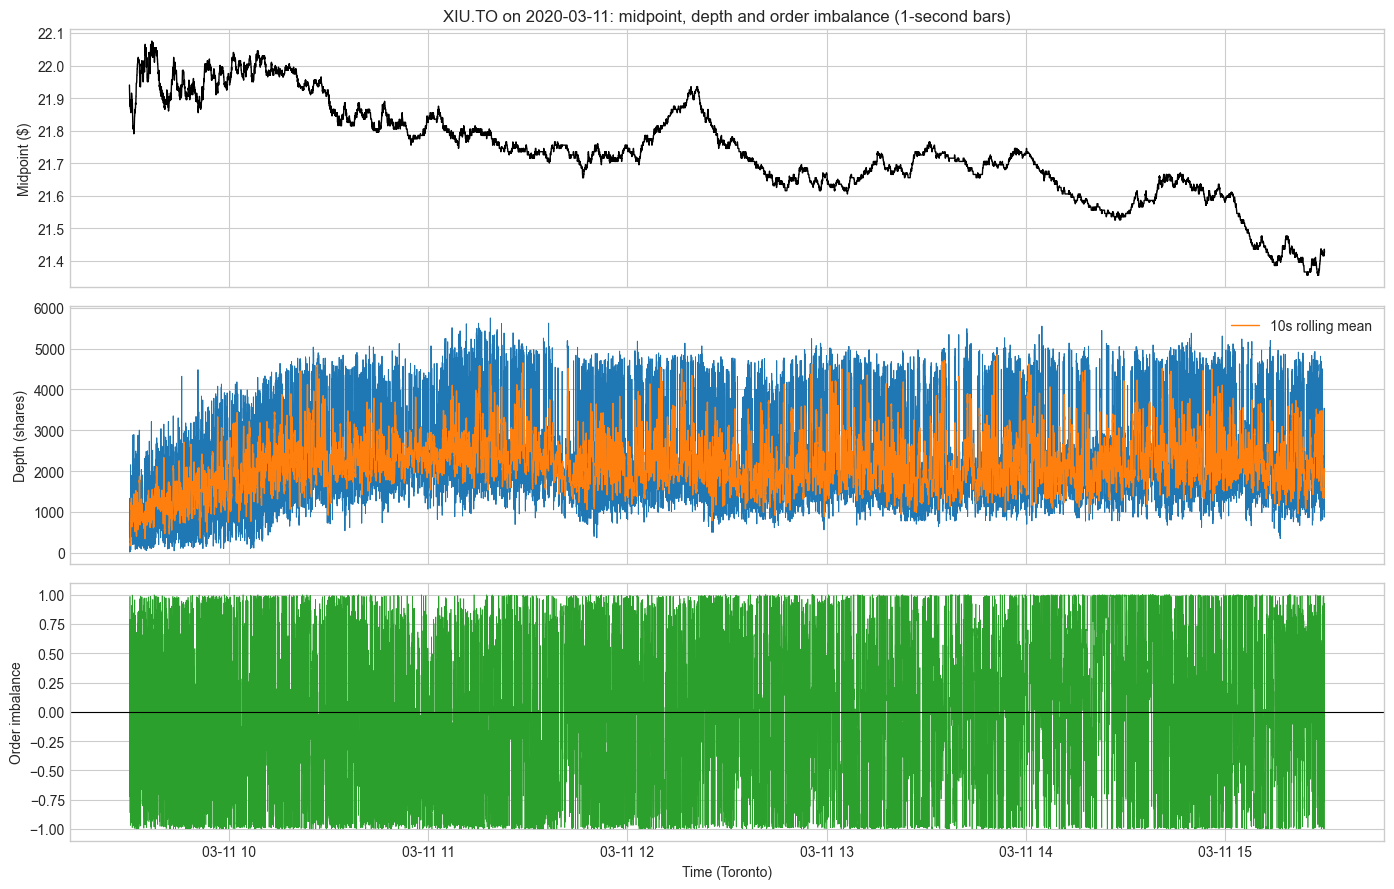

In [9]:
# Visual check of the day: midpoint, depth and order imbalance
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(book.index, book["Midpoint"], color="black", lw=1)
axes[0].set_ylabel("Midpoint ($)")
axes[0].set_title("XIU.TO on 2020-03-11: midpoint, depth and order imbalance (1-second bars)")

axes[1].plot(book.index, book["Depth"], color="tab:blue", lw=0.7)
axes[1].plot(book.index, book["Depth_MA10"], color="tab:orange", lw=1, label="10s rolling mean")
axes[1].set_ylabel("Depth (shares)")
axes[1].legend(loc="upper right")

axes[2].plot(book.index, book["OIB"], color="tab:green", lw=0.5)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_ylabel("Order imbalance")
axes[2].set_xlabel("Time (Toronto)")

plt.tight_layout()
plt.show()

## Logistic regression prediction (Q10-12)

Features: depth and its first difference, order imbalance and its first difference, the quoted bid-ask
spread, and the two "above the rolling mean" dummies. The target is `Tick`, the next-second uptick.

The sample is split **chronologically** into two equal halves rather than randomly: the first three hours
train the model, the last three hours test it. A random split would let the model learn from seconds that
come *after* the ones it is scored on, which is not a trade you could have made.

In [10]:
# Q10: build the estimation sample and split it into two equal halves
features = ["Depth", "Delta_Depth", "OIB", "Delta_OIB", "Spread",
            "Depth_Above_MA", "AbsOIB_Above_MA"]

# the last row has no "next second"; the first rows have no first difference / rolling mean
model_data = book.iloc[:-1].dropna(subset=features + ["Tick"]).copy()

split = len(model_data) // 2
train, test = model_data.iloc[:split], model_data.iloc[split:]

X_train, y_train = train[features], train["Tick"]
X_test,  y_test  = test[features],  test["Tick"]

print(f"Estimation sample : {len(model_data):,} seconds")
print(f"Train : {len(train):,} rows  ({train.index.min().time()} - {train.index.max().time()})  uptick rate {y_train.mean():.2%}")
print(f"Test  : {len(test):,} rows  ({test.index.min().time()} - {test.index.max().time()})  uptick rate {y_test.mean():.2%}")

Estimation sample : 21,598 seconds
Train : 10,799 rows  (09:30:01 - 12:29:59)  uptick rate 15.40%
Test  : 10,799 rows  (12:30:00 - 15:29:58)  uptick rate 9.91%


In [11]:
# Q11: estimate the logistic regression
logit = LogisticRegression(solver="lbfgs", max_iter=1000)
logit.fit(X_train, y_train)

coefs = pd.DataFrame({
    "coefficient": logit.coef_[0],
    "sd of feature": X_train.std().values,
    # effect on the log-odds of a one-standard-deviation move in the feature
    "std. coefficient": logit.coef_[0] * X_train.std().values,
}, index=features)
coefs["odds ratio (1 sd)"] = np.exp(coefs["std. coefficient"])

print(f"Intercept: {logit.intercept_[0]:.4f}")
coefs.sort_values("std. coefficient").round(4)

Intercept: -2.6512


,coefficient,sd of feature,std. coefficient,odds ratio (1 sd)
OIB,-1.2666,0.6571,-0.8323,0.4350
Delta_OIB,-0.2886,0.7171,-0.2070,0.8130
AbsOIB_Above_MA,-0.0727,0.4990,-0.0363,0.9644
Spread,0.0005,0.0002,0.0000,1.0000
Delta_Depth,0.0001,1149.9075,0.1427,1.1534
Depth,0.0001,1143.8885,0.1596,1.1730
Depth_Above_MA,0.4679,0.4938,0.2311,1.2599


In [12]:
# Q12: predicted probabilities and classification performance on the test sample
prob_test = logit.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, prob_test)
print(f"AUC                        : {auc:.4f}")
print(f"Accuracy at a 0.5 cutoff   : {accuracy_score(y_test, (prob_test > 0.5).astype(int)):.4f}")
print(f"Accuracy of 'never uptick' : {1 - y_test.mean():.4f}   <- naive benchmark")
print(f"Predicted probability range: [{prob_test.min():.4f}, {prob_test.max():.4f}]")
print()
print(classification_report(y_test, (prob_test > 0.5).astype(int),
                            target_names=["no uptick", "uptick"], digits=3, zero_division=0))

AUC                        : 0.7952
Accuracy at a 0.5 cutoff   : 0.9008
Accuracy of 'never uptick' : 0.9009   <- naive benchmark
Predicted probability range: [0.0097, 0.5218]

              precision    recall  f1-score   support

   no uptick      0.901     1.000     0.948      9729
      uptick      0.333     0.001     0.002      1070

    accuracy                          0.901     10799
   macro avg      0.617     0.500     0.475     10799
weighted avg      0.845     0.901     0.854     10799



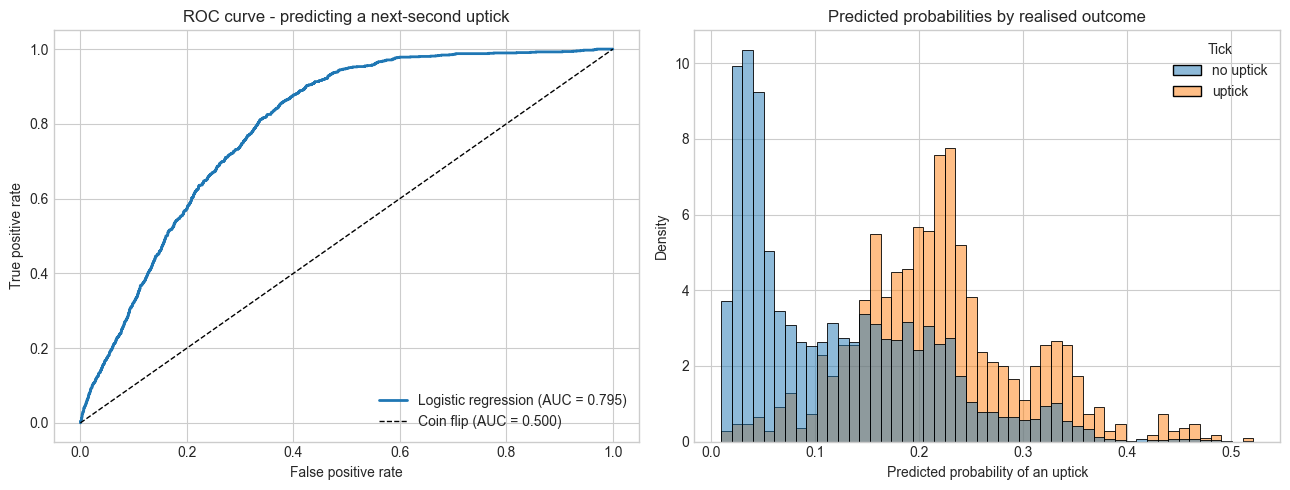

In [13]:
# Q12: ROC curve
fpr, tpr, _ = roc_curve(y_test, prob_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color="tab:blue", lw=2, label=f"Logistic regression (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="black", ls="--", lw=1, label="Coin flip (AUC = 0.500)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve - predicting a next-second uptick")
axes[0].legend(loc="lower right")

sns.histplot(x=prob_test, hue=y_test.map({0: "no uptick", 1: "uptick"}),
             bins=50, stat="density", common_norm=False, ax=axes[1])
axes[1].set_xlabel("Predicted probability of an uptick")
axes[1].set_title("Predicted probabilities by realised outcome")

plt.tight_layout()
plt.show()

### Assessing the predictive power

- The AUC is materially above 0.5, so the model **does** rank seconds correctly: a second that turns out to be
  followed by an uptick gets a higher score than a random other second roughly four times in five. Order
  imbalance carries almost all of that signal, and its sign is the one the theory predicts - a bid-heavy book
  (negative `OIB`, since the numerator is ask size minus bid size) pushes the midpoint up in the next second.
  This is the book-skew intuition from Day 2, estimated rather than assumed.
- Accuracy at the textbook 0.5 cutoff looks high, but it is no better than simply predicting "no uptick" every
  second - a hair worse, in fact, and it recalls almost none of the upticks. Upticks are rare (about one second
  in ten in the test half), so accuracy is the wrong yardstick, and the model almost never crosses 0.5 on its own. That is why the strategy below thresholds on a quantile of the
  predicted probability rather than on 0.5.
- The right-hand histogram is the more honest picture: the two distributions overlap heavily, but the uptick
  distribution is visibly shifted right. There is real information here - just not enough to separate the two
  classes cleanly.

## Testing the algorithm

Rule: at each second of the **test** sample, if the predicted probability of an uptick exceeds a threshold
$q$, buy one share and sell it in the next second. Because every position is unwound after one second, no
inventory accumulates. We set $q$ to the median predicted probability, so we trade in half of the seconds.

Two execution conventions:

1. **Midpoint execution** (frictionless): buy at $M_t$, sell at $M_{t+1}$.
2. **Realistic execution**: buy at the ask $A_t$, sell at the bid $B_{t+1}$ - paying the spread on every round trip.

In [14]:
# Set the threshold and mark the seconds we trade
strategy = test.copy()
strategy["prob_up"] = prob_test

q = np.median(prob_test)

# the next second's prices, at which the position is unwound
strategy["Midpoint_next"] = strategy["Midpoint"].shift(-1)
strategy["Bid_next"]      = strategy["Bid Price"].shift(-1)
strategy = strategy.iloc[:-1]        # the last second cannot be unwound

strategy["signal"] = (strategy["prob_up"] > q).astype(int)

trades = strategy[strategy["signal"] == 1].copy()
trades["pnl_mid"]  = trades["Midpoint_next"] - trades["Midpoint"]      # (1) midpoint to midpoint
trades["pnl_cost"] = trades["Bid_next"] - trades["Ask Price"]          # (2) buy the ask, sell the bid

print(f"Threshold q (median predicted probability): {q:.4f}")
print(f"Seconds evaluated : {len(strategy):,}")
print(f"Trades taken      : {len(trades):,}  ({len(trades)/len(strategy):.1%} of seconds)")
print(f"Realised uptick rate on traded seconds  : {trades['Tick'].mean():.2%}")
print(f"Realised uptick rate on skipped seconds : {strategy.loc[strategy['signal'] == 0, 'Tick'].mean():.2%}")

Threshold q (median predicted probability): 0.1153
Seconds evaluated : 10,798
Trades taken      : 5,399  (50.0% of seconds)
Realised uptick rate on traded seconds  : 18.19%
Realised uptick rate on skipped seconds : 1.63%


In [15]:
# Questions 1-3: profit and hit rates under both execution assumptions
summary = pd.DataFrame({
    "Midpoint execution": [
        trades["pnl_mid"].sum(),
        trades["pnl_mid"].mean(),
        (trades["pnl_mid"] > 0).sum(),
        (trades["pnl_mid"] == 0).sum(),
        (trades["pnl_mid"] < 0).sum(),
        (trades["pnl_mid"] > 0).mean(),
    ],
    "Ask-to-bid execution": [
        trades["pnl_cost"].sum(),
        trades["pnl_cost"].mean(),
        (trades["pnl_cost"] > 0).sum(),
        (trades["pnl_cost"] == 0).sum(),
        (trades["pnl_cost"] < 0).sum(),
        (trades["pnl_cost"] > 0).mean(),
    ],
}, index=["Total P&L ($ per share)", "Average P&L per trade ($)",
          "Profitable trades", "Break-even trades", "Losing trades",
          "Share of profitable trades"])

print(f"Average quoted spread paid per round trip : ${(trades['Ask Price'] - trades['Bid Price']).mean():.4f}")
print(f"Average gross edge per trade (midpoint)   : ${trades['pnl_mid'].mean():.6f}")
print(f"Edge as a share of the round-trip cost    : {trades['pnl_mid'].mean() / (trades['Ask Price'] - trades['Bid Price']).mean():.2%}")
summary.round(6)

Average quoted spread paid per round trip : $0.0136
Average gross edge per trade (midpoint)   : $0.000738
Edge as a share of the round-trip cost    : 5.41%


,Midpoint execution,Ask-to-bid execution
Total P&L ($ per share),3.985000,-67.900000
Average P&L per trade ($),0.000738,-0.012576
Profitable trades,982.000000,0.000000
Break-even trades,4030.000000,206.000000
Losing trades,387.000000,5193.000000
Share of profitable trades,0.181886,0.000000


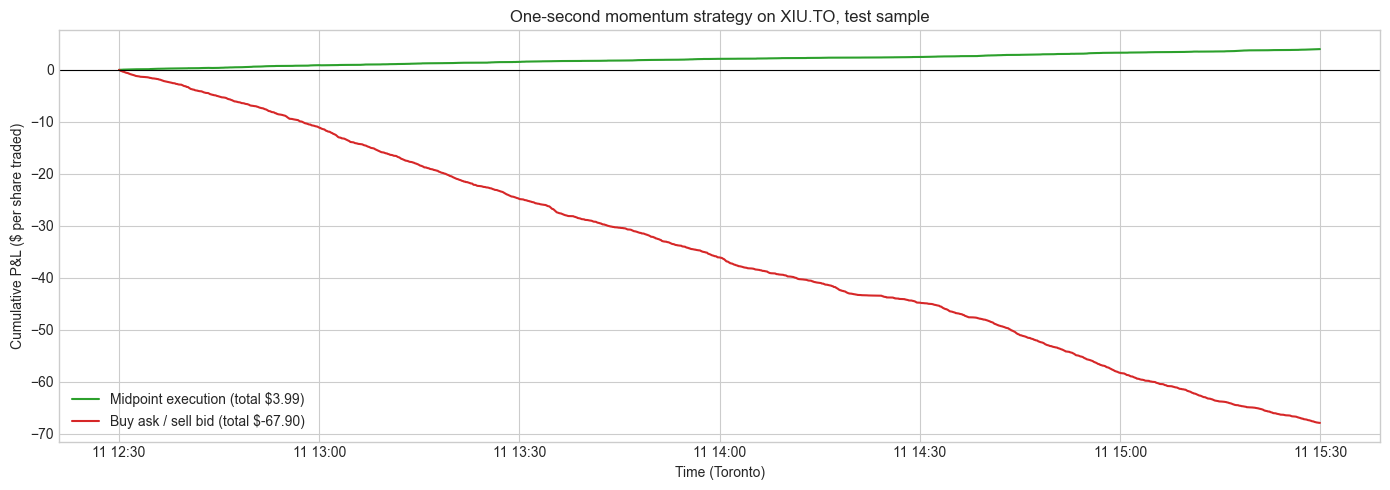

In [16]:
# Cumulative P&L of the strategy under both conventions
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(trades.index, trades["pnl_mid"].cumsum(), color="tab:green", lw=1.5,
        label=f"Midpoint execution (total ${trades['pnl_mid'].sum():,.2f})")
ax.plot(trades.index, trades["pnl_cost"].cumsum(), color="tab:red", lw=1.5,
        label=f"Buy ask / sell bid (total ${trades['pnl_cost'].sum():,.2f})")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Time (Toronto)")
ax.set_ylabel("Cumulative P&L ($ per share traded)")
ax.set_title("One-second momentum strategy on XIU.TO, test sample")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [17]:
# Does trading only on stronger signals help?
rows = []
for pct in [50, 75, 90, 95, 99]:
    thr = np.percentile(prob_test, pct)
    sel = strategy[strategy["prob_up"] > thr]
    pnl_mid  = sel["Midpoint_next"] - sel["Midpoint"]
    pnl_cost = sel["Bid_next"] - sel["Ask Price"]
    rows.append({
        "threshold pct": pct,
        "q": thr,
        "trades": len(sel),
        "P&L at mid ($)": pnl_mid.sum(),
        "P&L per trade at mid ($)": pnl_mid.mean(),
        "P&L with spread ($)": pnl_cost.sum(),
        "profitable trades at mid": (pnl_mid > 0).sum(),
        "profitable trades with spread": (pnl_cost > 0).sum(),
    })

pd.DataFrame(rows).set_index("threshold pct").round(6)

,q,trades,P&L at mid ($),P&L per trade at mid ($),P&L with spread ($),profitable trades at mid,profitable trades with spread
threshold pct,,,,,,,
50,0.115349,5399,3.985,0.000738,-67.90,982,0
75,0.198101,2700,3.635,0.001346,-29.89,645,0
90,0.255087,1080,1.720,0.001593,-11.58,281,0
95,0.317781,540,1.110,0.002056,-5.04,154,0
99,0.370033,108,0.335,0.003102,-0.85,43,0


### Answers

1. **Buying and selling at the midpoint**, the strategy makes a small positive profit over the test half-day
   (see `Total P&L` above): about $4 per share traded across 5,399 round trips. The edge is real but tiny in
   dollar terms - roughly $0.0007, under a tenth of a cent, per share per trade.
2. **Buying at the ask and selling at the bid**, the same trades lose money by a wide margin. Every round trip
   pays the full quoted spread, which on XIU.TO that day averaged more than a cent - an order of magnitude
   larger than the average gross edge, as the "edge as a share of the round-trip cost" line shows.
3. **Profitable trades.** At the midpoint, about 18% of trades make money, three quarters break even exactly
   (the midpoint simply does not move in most seconds), and the remainder lose - the positive total comes from
   the winners outnumbering the losers by more than two to one. Once the spread is crossed, **zero** trades are
   profitable; a couple of hundred break even, and everything else loses. To make money you would need the bid
   one second later to sit at or above the ask you just paid - a full-spread move inside a single second - which
   effectively never happens on a liquid ETF. Raising the threshold to trade only on the strongest 1% of signals
   does not change this: it roughly quadruples the per-trade edge at the midpoint, and still leaves it four
   times short of the spread, with no profitable trades at any threshold.

### Reflection: predictive power vs. strategy implementation

The ROC curve and the P&L tell two different stories, and both are correct.

**The model has genuine predictive power.** An AUC near 0.8 on tick direction is not luck - order imbalance
really does forecast the next second's midpoint move. If the question is "does the limit order book carry
information about short-horizon prices?", this exercise answers yes.

**The strategy is still not viable.** The gap between the two P&L numbers is entirely the bid-ask spread. The
signal shifts the *expected* midpoint by a fraction of a cent, while the round trip costs more than a cent. A
strategy needs the prediction to be worth more than the cost of acting on it, and this one falls short by more
than an order of magnitude.

**What this implies more generally.**

- Statistical significance and economic significance are different things. A model can be right far more often
  than chance and still lose money, because accuracy is measured in probabilities and trading is settled in
  dollars net of costs.
- Transaction costs are not a haircut applied at the end of a backtest; they set the bar the signal has to
  clear in the first place. Comparing the expected move to the round-trip cost is the first test to run, not
  the last - it would have ruled this strategy out before any model was fitted.
- A signal this weak can only be monetised by *not* paying the spread - by posting limit orders and earning the
  spread instead of crossing it. That turns the problem into market making, where the forecast is used to skew
  quotes and manage adverse selection rather than to fire off marketable orders. The same model that loses money
  as a taker can be valuable as a maker.
- The horizon matters too. Predicting one second ahead means paying the spread up to 3,600 times an hour.
  Signals worth trading are ones that persist long enough to amortise the cost of getting in and out.